# Проект: вариант 1

# Анализ мобильной игры

Три задания: retention, A/B-тест и метрики события.
Для запуска положите исходные CSV рядом с ноутбуком или в папку `upload`.
Нужны pandas, numpy, scipy и matplotlib.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = Path('upload') if Path('upload').is_dir() else Path('.')


### Загрузка и проверка данных

In [3]:
registrations = pd.read_csv(DATA_DIR / 'problem1-reg_data.csv', sep=';')
logins = pd.read_csv(DATA_DIR / 'problem1-auth_data.csv', sep=';')
ab_data = pd.read_csv(DATA_DIR / 'Проект_1_Задание_2.csv', sep=';')

assert not ab_data.isna().any().any(), 'В A/B-данных есть пропуски'
assert ab_data['user_id'].is_unique, 'Пользователь встречается несколько раз'
assert set(ab_data['testgroup']) == {'a', 'b'}, 'Неожиданные группы'
assert np.isfinite(ab_data['revenue']).all(), 'Некорректная выручка'
assert (ab_data['revenue'] >= 0).all(), 'Есть отрицательная выручка'

print(f'Регистрации: {len(registrations):,}')
print(f'Входы: {len(logins):,}')
print(f'Участники A/B-теста: {len(ab_data):,}')


Регистрации: 1,000,000
Входы: 506,739
Участники A/B-теста: 404,770


## 1. Retention

Retention Dn — доля игроков, вошедших именно в календарный день n после
регистрации (UTC). Повторные входы считаются один раз.

Последний день выгрузки неполный, поэтому исключаем 23.09.2020.
Предполагаем, что предыдущие дни выгружены полностью. Для молодых когорт
ненаблюдаемые дни обозначаем `NaN`, а не нулём.


In [4]:
def retention(registrations, logins, *, observation_end, max_day=30):
    """Удержание по календарным дням UTC, от D0 до max_day.

    observation_end — начало первого неполного дня (он исключается).
    Возвращает таблицу когорт, размеры когорт и сводку. Доли — от 0 до 1.
    Ненаблюдаемые дни — NaN; дни без входов — 0.
    """
    end_date = pd.to_datetime(observation_end, utc=True)
    if pd.isna(end_date) or end_date != end_date.normalize():
        raise ValueError('observation_end должен быть полуночью UTC')
    if not isinstance(max_day, int) or max_day < 0:
        raise ValueError('max_day должен быть целым неотрицательным числом')

    registrations = registrations[['uid', 'reg_ts']].copy()
    logins = logins[['uid', 'auth_ts']]
    if registrations.isna().any().any() or logins.isna().any().any():
        raise ValueError('В данных есть пропуски')

    # 1. Для каждого входа определяем дату регистрации и день жизни.
    registrations['cohort'] = pd.to_datetime(
        registrations['reg_ts'], unit='s', utc=True
    ).dt.normalize()
    activity = logins.merge(
        registrations, on='uid', how='left', validate='many_to_one'
    )
    if activity['reg_ts'].isna().any():
        raise ValueError('Есть входы пользователей без регистрации')
    if (activity['auth_ts'] < activity['reg_ts']).any():
        raise ValueError('Есть входы до регистрации')

    activity = activity.loc[activity['auth_ts'] < end_date.timestamp()].copy()
    login_dates = pd.to_datetime(activity['auth_ts'], unit='s', utc=True)
    activity['day'] = (login_dates.dt.normalize() - activity['cohort']).dt.days
    activity = activity.loc[activity['day'].between(0, max_day)]
    activity = activity.drop_duplicates(['uid', 'day'])

    # 2. Считаем размеры когорт и уникальных вернувшихся игроков.
    complete_registrations = registrations.loc[registrations['cohort'] < end_date]
    cohort_sizes = complete_registrations.groupby('cohort').size()
    if cohort_sizes.empty:
        raise ValueError('Нет регистраций до observation_end')

    days = pd.Index(range(max_day + 1), name='day')
    counts = activity.groupby(['cohort', 'day']).size().unstack('day')
    counts = counts.reindex(index=cohort_sizes.index, columns=days).fillna(0)

    # 3. Исключаем дни, которые ещё не успели полностью пройти.
    for day in days:
        immature = counts.index + pd.Timedelta(days=day) >= end_date
        counts.loc[immature, day] = np.nan

    eligible_users = counts.notna().mul(cohort_sizes, axis=0).sum()
    returned_users = counts.sum(min_count=1)
    summary = pd.DataFrame({
        'eligible_users': eligible_users,
        'returned_users': returned_users,
        'retention': returned_users / eligible_users.replace(0, np.nan),
    })
    return {
        'rates': counts.div(cohort_sizes, axis=0),
        'counts': counts,
        'cohort_sizes': cohort_sizes,
        'summary': summary,
    }

In [5]:
cutoff = pd.to_datetime(logins['auth_ts'].max(), unit='s', utc=True).normalize()
result = retention(registrations, logins, observation_end=cutoff, max_day=30)

key_days = [1, 3, 7, 14, 30]
summary = result['summary'].loc[key_days].copy()
summary['retention, %'] = summary.pop('retention') * 100
print(summary.round(3).to_string())


     eligible_users  returned_users  retention, %
day                                              
1             54122          1101.0         2.034
3             53944          2501.0         4.636
7             53590          3177.0         5.928
14            52977          2511.0         4.740
30            51601          1502.0         2.911


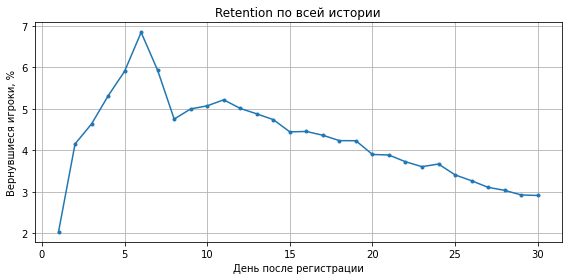

In [6]:
curve = result['summary']['retention'].loc[1:] * 100
curve.plot(figsize=(8, 4), marker='.', grid=True)
plt.title('Retention по всей истории')
plt.xlabel('День после регистрации')
plt.ylabel('Вернувшиеся игроки, %')
plt.tight_layout()
plt.show()


**Результат:** D1 — 2,01%, D7 — 5,88%, D30 — 2,83%.
Знаменатель каждого дня включает только созревшие когорты.
D7 может быть выше D1: игрок не обязан возвращаться каждый день.
История охватывает 1998–2020 годы, поэтому для текущих продуктовых решений
нужен отдельный анализ недавних когорт.


## 2. A/B-тест

По условию `a` — контроль, `b` — тест. Считаем:

- **ARPU:** выручка / все пользователи — основная метрика.
- **Конверсия:** плательщики / все пользователи.
- **ARPPU:** выручка / плательщики — объясняет изменение ARPU.

Проверяем ARPU тестом Welch, конверсию — χ² без поправки Йейтса.
Оба теста двусторонние, уровень значимости 0,05.
Предполагаем случайное назначение и одинаковое окно выручки; в файле нет
данных для проверки этих условий. Крупные платежи не удаляем.


In [7]:
def summarize_ab(data):
    """Количество игроков, выручка, ARPU, конверсия и ARPPU по группам."""
    groups = data.assign(is_payer=data['revenue'] > 0).groupby('testgroup')
    metrics = groups.agg(
        users=('user_id', 'size'),
        payers=('is_payer', 'sum'),
        revenue=('revenue', 'sum'),
    )
    metrics['arpu'] = metrics['revenue'] / metrics['users']
    metrics['conversion'] = metrics['payers'] / metrics['users']
    metrics['arppu'] = metrics['revenue'] / metrics['payers'].replace(0, np.nan)
    return metrics

In [8]:
metrics = summarize_ab(ab_data)
print(metrics.round(4).to_string())


            users  payers  revenue     arpu  conversion      arppu
testgroup                                                         
a          202103    1928  5136189  25.4137      0.0095  2663.9984
b          202667    1805  5421603  26.7513      0.0089  3003.6582


### Проверка различий

In [9]:
def compare_groups(data):
    """Двусторонние тесты: Welch для ARPU, χ² для доли плательщиков."""
    control = data.loc[data['testgroup'] == 'a', 'revenue']
    treatment = data.loc[data['testgroup'] == 'b', 'revenue']

    arpu_test = stats.ttest_ind(treatment, control, equal_var=False)
    interval = arpu_test.confidence_interval(confidence_level=0.95)

    payer_table = pd.crosstab(data['testgroup'], data['revenue'] > 0)
    conversion_test = stats.chi2_contingency(payer_table, correction=False)

    return pd.Series({
        'ARPU: разница B − A': treatment.mean() - control.mean(),
        'ARPU: нижняя граница 95% ДИ': interval.low,
        'ARPU: верхняя граница 95% ДИ': interval.high,
        'ARPU: p-value': arpu_test.pvalue,
        'Конверсия: p-value': conversion_test.pvalue,
    })

In [10]:
test_results = compare_groups(ab_data)
print(test_results.round(4).to_string())

large_payers = ab_data.loc[
    (ab_data['testgroup'] == 'a') & (ab_data['revenue'] > 10_000)
]
revenue_share = large_payers['revenue'].sum() / metrics.loc['a', 'revenue']
print(f'Крупных плательщиков в контроле: {len(large_payers)}')
print(f'Их доля выручки: {revenue_share:.2%}')


ARPU: разница B − A             1.3376
ARPU: нижняя граница 95% ДИ    -2.8672
ARPU: верхняя граница 95% ДИ    5.5423
ARPU: p-value                   0.5330
Конверсия: p-value              0.0350
Крупных плательщиков в контроле: 123
Их доля выручки: 89.37%


**Вывод:** ARPU вырос на 5,26%, но преимущество не подтверждено:
p = 0,533; 95% ДИ разницы B − A: [−2,87; 5,54].

Конверсия снизилась с 0,954% до 0,891% (p = 0,035).
При поправке Бонферрони на две проверки p ≈ 0,070 — значимость не сохраняется.
ARPPU выше на 12,75%, но состав плательщиков зависит от предложения.

В контроле 123 игрока дают 89,37% выручки — это причина большой неопределённости.
Нужно проверить происхождение крупных платежей. Пока разумно сохранить
контроль; это не доказанная победа A. Следующий тест следует заранее спланировать
по минимальному полезному эффекту ARPU и защитным метрикам конверсии и retention.


## 3. Метрики тематического события

Фактических данных события нет. Предлагаю следующие показатели:

| Метрика | Расчёт |
|---|---|
| Участие | Начавшие событие / активные игроки с доступом к нему |
| Завершение | Прошедшие событие до дедлайна / участники |
| Сложность | Успешные попытки / завершённые попытки; попытки и время на уровень |
| Награды | Получившие награду / выполнившие условия |
| Удержание | Возврат в событие на D1/D7; возврат в игру после события |
| Монетизация | ARPU всей игры, конверсия и ARPPU за одинаковое окно |
| Качество | Сбои, ошибки наград и обращения на 1000 участников |

Для возвратов нужны полные окна наблюдения; поздних участников оцениваем
отдельно. Лучше сравнивать со случайной контрольной группой, включая всех
назначенных игроков. Сравнение с предыдущим событием без контроля не доказывает
причинный эффект.

**При откате уровней** сохраняем базовые метрики и добавляем:

- долю игроков с откатами и число потерянных уровней;
- долю попыток на уже пройденных уровнях;
- время и число попыток до восстановления позиции;
- долю не вернувшихся за 24 часа после отката, при полном окне наблюдения.

Воронку строим по первому достижению уровня. Новую механику проверяем A/B-тестом
при одинаковых наградах и сроках. Рост покупок бустеров сам по себе не означает
успех, если ухудшились удержание и завершение события.
